In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as col
from mpl_toolkits.mplot3d import Axes3D
import json
import numpy as np
import pandas as pd
import time
import scipy

In [2]:
def plot_naive(file):
	# retrieve data
	with open(file, 'r') as f:
		data = json.load(f)
		
		x = [item['x'] for item in data]
		y = [item['y'] for item in data]

	# plot
	plt.figure(figsize=(25, 6))
	plt.plot(x, y)
	plt.title(f"Signal: $G(x) = \\cos(2\\pi \\cdot 3x)$")
	plt.xlabel("Time (s)")
	plt.grid(True)
	plt.show()

In [3]:
def plot_2D(file):
	# retrieve data
	with open(file, 'r') as f:
		data = json.load(f)
		
		x = [item['x'] for item in data]
		y = [item['y'] for item in data]
		Gxy = [item['z'] for item in data]

		colors = ["#4a6fa5", 'white', "#db7a57"]
		cmap = col.LinearSegmentedColormap.from_list('custom', colors, N=256)

		# plot
		fig = plt.figure(figsize=(12, 8))
		ax = fig.add_subplot(111, projection='3d')

		# Plot the surface
		surf = ax.plot_surface(np.array(x).reshape((int(np.sqrt(len(x))), int(np.sqrt(len(x))))),
						 	   np.array(y).reshape((int(np.sqrt(len(y))), int(np.sqrt(len(y))))),
							   np.array(Gxy).reshape((int(np.sqrt(len(Gxy))), int(np.sqrt(len(Gxy))))),
							   cmap=cmap, antialiased=True, shade=True)

		# Add labels and formatting
		ax.set_title('$G(x, y) = \\cos(2\\pi f_x x) \\cos(2\\pi f_y y)$')
		ax.set_xlabel('x')
		ax.set_ylabel('y')
		ax.set_zlabel('G(x, y)')
		fig.colorbar(surf, shrink=0.5, aspect=10)
		ax.set_facecolor('white')
		# Clean panes
		for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
			axis.pane.fill = False
			axis.pane.set_edgecolor('lightgray')

		# Custom grid
		for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
			axis._axinfo['grid'].update({
				'color': 'lightgray',
				'linestyle': '--',
				'linewidth': 0.8
			})
		plt.savefig('dataset.png', dpi=300)
		plt.show()
		

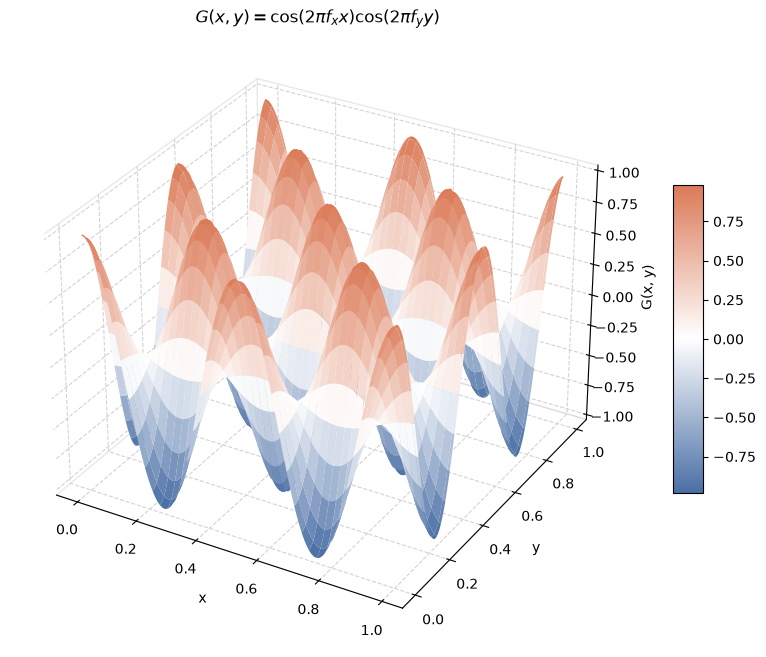

In [5]:
plot_2D('Gxy_vs_xy.json')   ### this image was generated with N=128 and fx, fy=2

In [6]:
def plot_fft(file):
	# retrieve data
	with open(file, 'r') as f:
		data = json.load(f)
		
		x = [item['x'] for item in data]
		y = [item['abs'] for item in data]

		plt.stem(range(len(x)), y) # Plot positive frequencies
		plt.title("FFT Magnitude Spectrum")
		plt.xlabel("Frequency (Hz)")
		plt.ylabel("|X(k)|")
		plt.grid(True)
		plt.show()

In [7]:
def plot_fft_2D(file):
	# retrieve data
	with open(file, 'r') as f:
		data = json.load(f)
		
		x = [item['x'] for item in data]
		y = [item['y'] for item in data]
		z = [item['z'] for item in data]

		fig = plt.figure(figsize=(12, 8))
		ax = fig.add_subplot(111, projection='3d')

		# Draw the 'heads' of the stems
		ax.scatter(x, y, z, color='blue', s=30, label='FFT Peaks')

		# Draw the 'stems' (lines from the floor to the peak)
		for xi, yi, zi in zip(x, y, z):
		    ax.plot([xi, xi], [yi, yi], [0, zi], color='black', alpha=0.6, linewidth=1)

		# Formatting
		ax.set_title("3D Stem Plot of 2D FFT ($X_{kl}$)")
		ax.set_xlabel('Frequency $f_x$')
		ax.set_ylabel('Frequency $f_y$')
		ax.set_zlabel('Magnitude')
		ax.set_zlim(0, 17)
		ax.view_init(elev=25, azim=50)

		plt.tight_layout()
		plt.show()


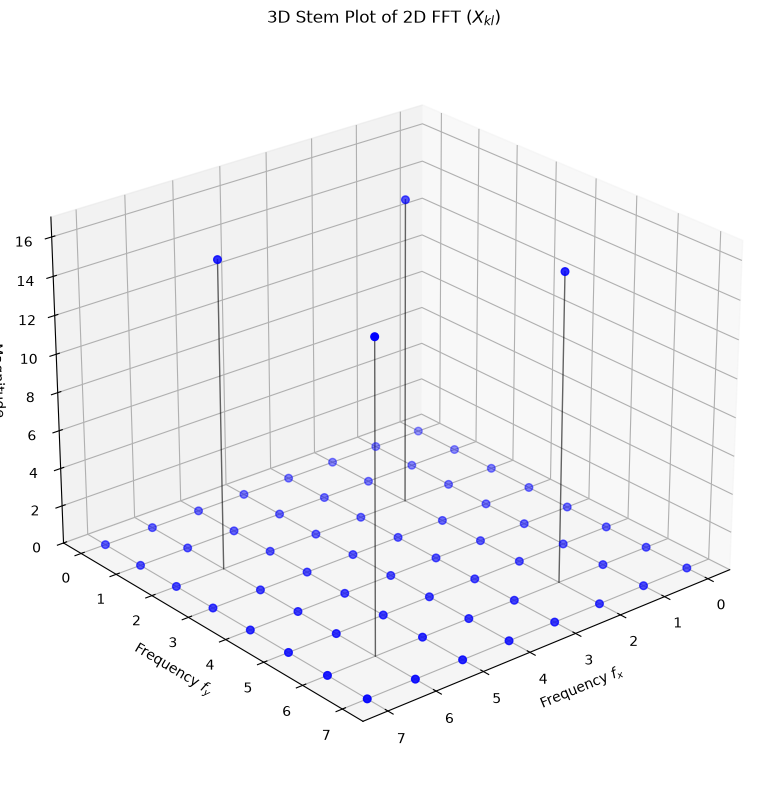

In [12]:
plot = True
if plot:
    plot_fft_2D('fft_res_omp.json')

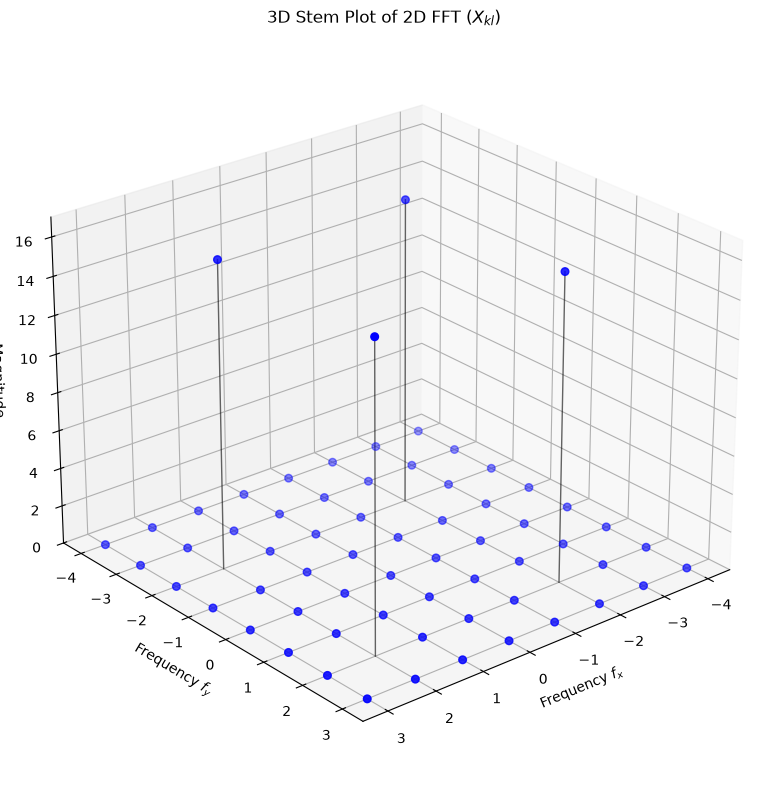

In [13]:
plot = True
if plot:
    plot_fft_2D('fft_res_omp_shift.json')

In [15]:
def plot_benchmark_serial(file1, file2):
	try:
		df1 = pd.read_csv(file1)
		df2 = pd.read_csv(file2)
	except Exception as e:
		print(f"Error reading file: {e}")
		return

	x = np.arange(64, 4096)

	def model(x, a):
		return a * x**2 * np.log(x)

	N = np.unique(df1['N'])

	mean_time1 = df1.groupby('N')['ExecutionTime'].mean().values
	mean_time2 = df2.groupby('N')['ExecutionTime'].mean().values

	std_time1 = df1.groupby('N')['ExecutionTime'].std().values
	std_time2 = df2.groupby('N')['ExecutionTime'].std().values

	# print(mean_time1)
	# print(mean_time2)

	a1, _ = scipy.optimize.curve_fit(model, N, mean_time1, sigma=std_time1)
	a2, _ = scipy.optimize.curve_fit(model, N, mean_time2, sigma=std_time2)

	# 2. Create the visualization
	plt.figure(figsize=(10, 6))
	plt.errorbar(N, mean_time1, yerr=std_time1,
				fmt='o',
				ms=5,
				capsize=3,
				color='firebrick', 
				label='iterative FFT serial',
				zorder=2)
	plt.errorbar(N, mean_time2, yerr=std_time2,
				fmt='s',
				ms=5,
				capsize=3,
				color="mediumblue", 
				label='ditfft2 FFT serial',
				zorder=2)
	plt.plot(x, a1*x*x*np.log(x), 
			linestyle='-',        # Solid line
			color="lightcoral",      # Red color
			linewidth=1, 
			label='$\\mathcal{O}(N^2\\log N)$',
			zorder=2)
	plt.plot(x, a2*x*x*np.log(x), 
			linestyle='-',        # Solid line
			color="skyblue",      # Red color
			linewidth=1, 
			label='$\\mathcal{O}(N^2\\log N)$',
			zorder=1)

	

	# 3. Add labels and styling
	plt.title('Algorithm Performance Analysis', fontsize=14)
	plt.xlabel('Matrix Size (N)', fontsize=12)
	plt.ylabel('Execution Time (seconds)', fontsize=12)
	plt.xscale('log', base=2)
	plt.grid(True, linestyle='--', alpha=0.5)
	plt.legend()

	# 4. Show the result	
	plt.show()

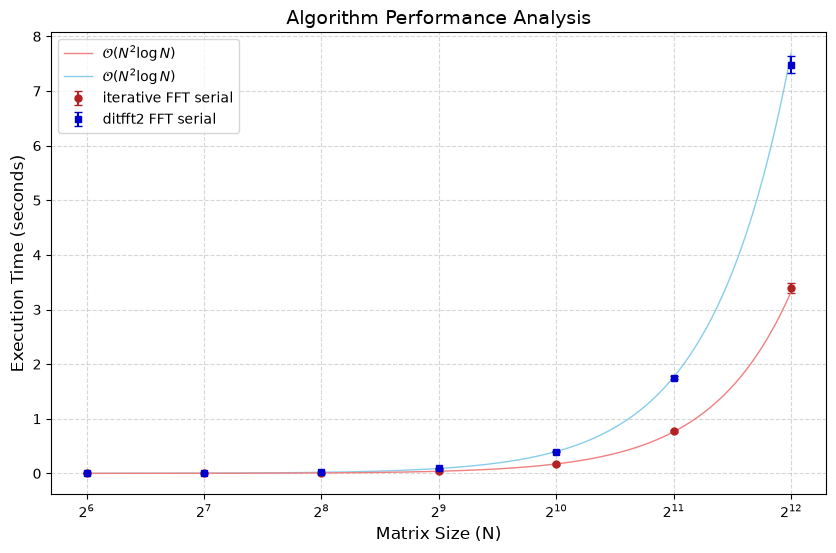

In [19]:
## using bit-reversal and precomputation of twiddle takes half of the time
plot_benchmark_serial("benchmark/results_iterative_fft.csv", 'benchmark/results_ditfft2.csv')

In [27]:
def plot_benchmark_openmp(file, n, marker, color, linecolor):
	try:
		df = pd.read_csv(file)
		
	except Exception as e:
		print(f"Error reading file: {e}")
		return

	x = np.arange(1, 16.1, 0.1)

	### Amdahl's law
	def model(x, a, b):
		return a / x + b
	

	n_threads = np.unique(df['NThreads'])

	mean_time = df[df['N']==n].groupby('NThreads')['ExecutionTime'].mean().values

	std_time = df[df['N']==n].groupby('NThreads')['ExecutionTime'].std().values

	(a, b), _ = scipy.optimize.curve_fit(model, n_threads, mean_time, sigma=std_time)


	# 2. Create the visualization
	plt.figure(figsize=(10, 6))
	plt.errorbar(n_threads, mean_time, yerr=std_time,
				fmt=marker,
				ms=5,
				capsize=3,
				color=color, 
				label='iterative FFT openMP',
				zorder=2)
	plt.plot(x, a / x + b, 
			linestyle='-',        # Solid line
			color=linecolor,      # Red color
			linewidth=1, 
			label='Amdahl\'s law',
			zorder=2)


	# 3. Add labels and styling
	plt.title(f'Algorithm Performance Analysis, N = {n}', fontsize=14)
	plt.xlabel('Number of threads', fontsize=12)
	plt.ylabel('Execution Time (seconds)', fontsize=12)
	# plt.xscale('log', base=2)
	plt.grid(True, linestyle='--', alpha=0.5)
	plt.legend()

	# 4. Show the result	
	plt.show()

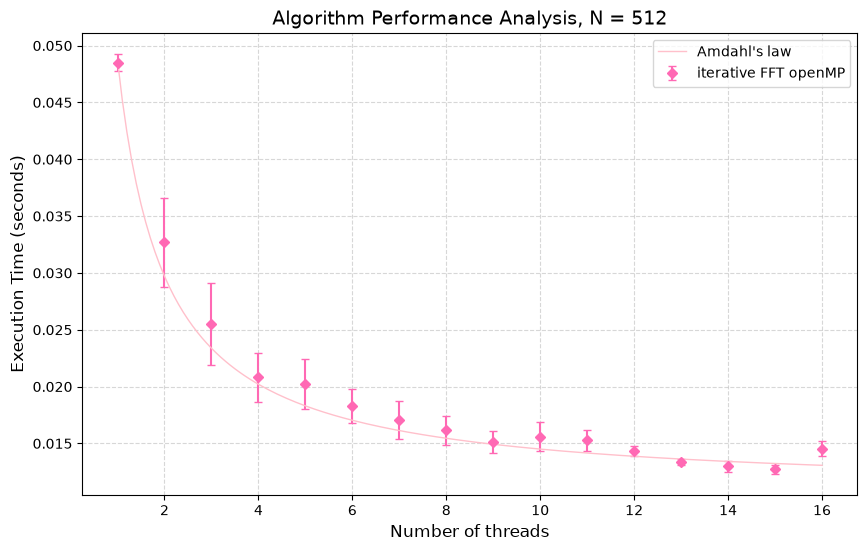

In [28]:
plot_benchmark_openmp("benchmark/results_openmp.csv", 512, 'D', 'hotpink', 'pink')

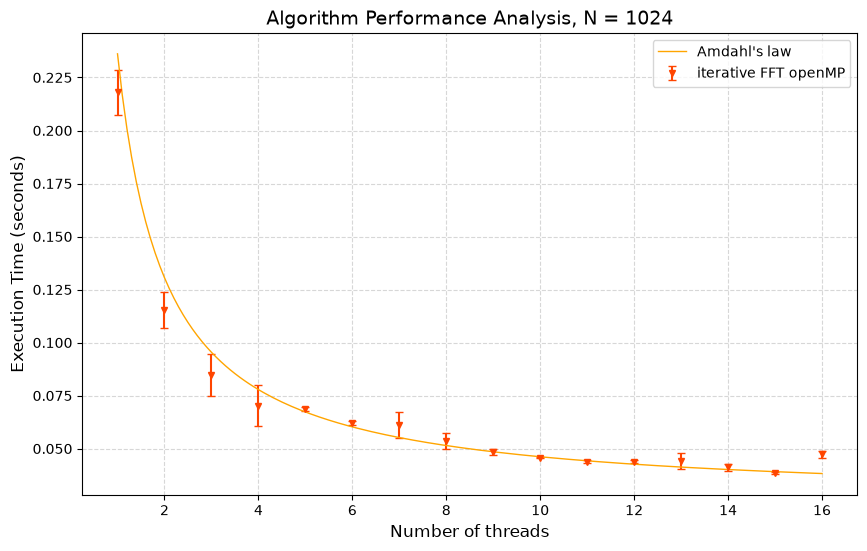

In [29]:
plot_benchmark_openmp("benchmark/results_openmp.csv", 1024, 'v', 'orangered', 'orange')

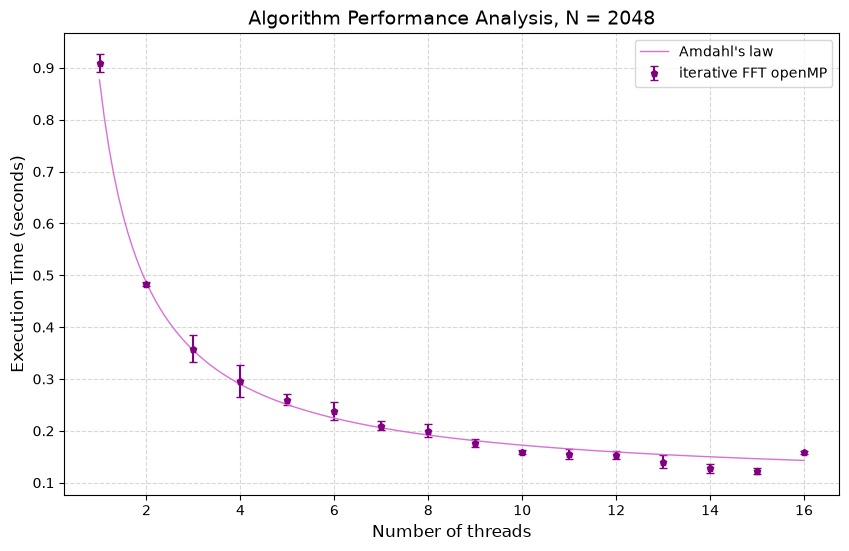

In [30]:
plot_benchmark_openmp("benchmark/results_openmp.csv", 2048, 'p', 'purple', 'orchid')

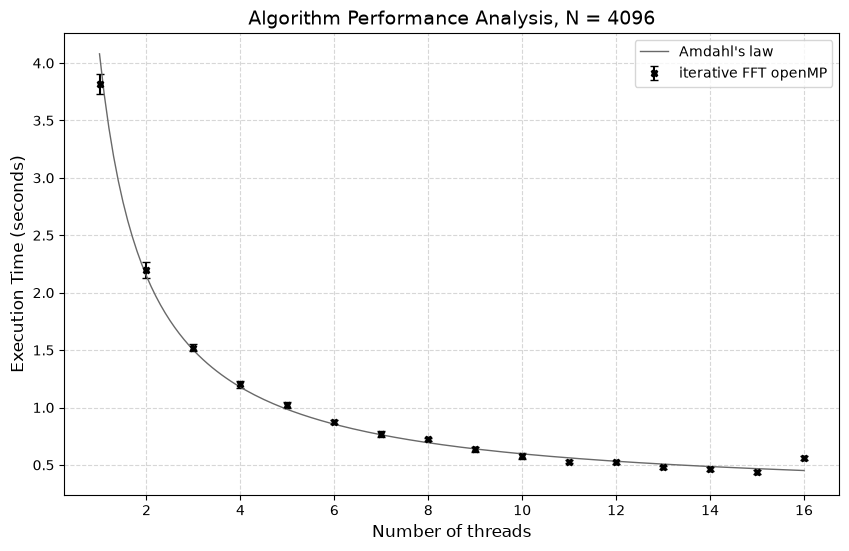

In [31]:
plot_benchmark_openmp("benchmark/results_openmp.csv", 4096, 'X', 'black', 'dimgrey')

In [32]:
def plot_openmp_nthreads(file):
	try:
		df = pd.read_csv(file)
		
	except Exception as e:
		print(f"Error reading file: {e}")
		return
	

	n_threads = np.unique(df['NThreads'])

	mean_time = df.groupby(['NThreads', 'N'])['ExecutionTime'].mean().reset_index()
	std_time = df.groupby(['NThreads', 'N'])['ExecutionTime'].std().reset_index()

	markers = ['o', 's', '^', 'D', 'v', 'p', 'X']
	colors = ['forestgreen', 'red', 'blue', 'hotpink', 'orangered', 'purple', 'black']

	plt.figure(figsize=(10, 6))
	for i, (n, group) in enumerate(mean_time.groupby('N')):
		std = std_time[std_time['N'] == n]['ExecutionTime'].values
		plt.errorbar(n_threads, group['ExecutionTime'], yerr=std,
				fmt=markers[i % len(markers)],
				ms=5,
				capsize=3,
				color=colors[i % len(colors)],
				label=f'N={n}')

	plt.xlabel('Number of Threads')
	plt.ylabel('Execution Time (s)')
	plt.yscale('log')
	plt.title('Execution Time vs Threads')
	plt.grid(True, linestyle='--', alpha=0.5)
	plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
	plt.show()

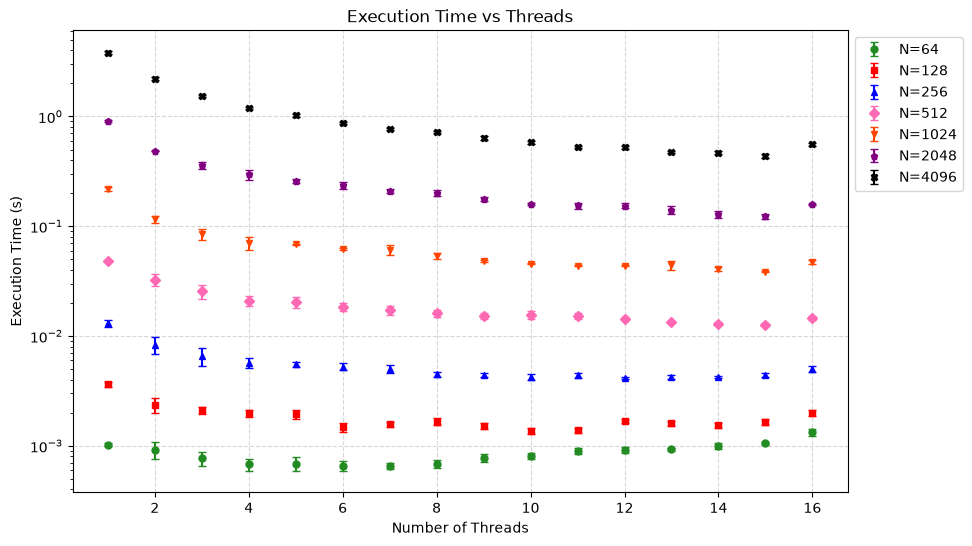

In [33]:
plot_openmp_nthreads('benchmark/results_openmp.csv')

In [2]:
def plot_benchmark_cuda(file):
	try:
		df = pd.read_csv(file)
		
	except Exception as e:
		print(f"Error reading file: {e}")
		return


	n_tpb = np.unique(df['NThreadsPerBlock'])

	mean_time = df.groupby('NThreadsPerBlock')['ExecutionTime'].mean().values

	std_time = df.groupby('NThreadsPerBlock')['ExecutionTime'].std().values


	# 2. Create the visualization
	plt.figure(figsize=(10, 6))
	plt.errorbar(n_tpb, mean_time, yerr=std_time,
				fmt='o',
				ms=5,
				capsize=3,
				color='red', 
				#label='iterative FFT openMP',
				zorder=2)


	# 3. Add labels and styling
	plt.title('Tuning Number of Thread per Block, N = 512', fontsize=14)
	plt.xlabel('Number of threads per block', fontsize=12)
	plt.ylabel('Execution Time (seconds)', fontsize=12)
	plt.xscale('log', base=2)
	plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
	plt.xticks(n_tpb, labels=['32', '64', '128', '256'])
	plt.grid(True, linestyle='--', alpha=0.5)
	plt.legend()

	# 4. Show the result	
	plt.show()

/tmp/ipykernel_25820/14390540.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


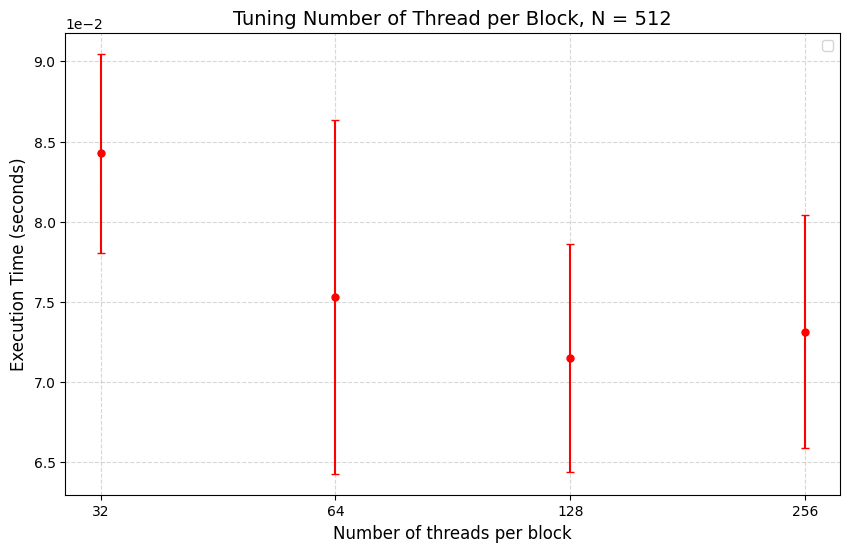

In [3]:
plot_benchmark_cuda('benchmark/results_tune_tpb.csv')